In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = Path("../data/dirty_cafe_sales.csv")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Loading Data

In [28]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns")
df.head()

Loaded 10,000 rows and 8 columns


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


##  Initial Data Exploration

Before touching anything, i have to understand exactly how messy this dataset is:
column types, missing values, duplicates, and what "junk" values are hiding in it.


In [29]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Rows: 10000
Columns: 8

Column names: ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']

Data types:
Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [6]:
df.describe(include="all").T

,count,unique,top,freq
Transaction ID,10000,10000,TXN_1961373,1
Item,9667,10,Juice,1171
Quantity,9862,7,5,2013
Price Per Unit,9821,8,3.0,2429
Total Spent,9827,19,6.0,979
Payment Method,7421,5,Digital Wallet,2291
Location,6735,4,Takeaway,3022
Transaction Date,9841,367,UNKNOWN,159


In [30]:
missing_raw = df.isnull().sum()
print("Missing values (blank/NaN only, before we deal with 'ERROR'/'UNKNOWN'):")
missing_raw[missing_raw > 0]

Missing values (blank/NaN only, before we deal with 'ERROR'/'UNKNOWN'):


Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [8]:
duplicate_rows = df.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_rows}")


Exact duplicate rows: 0


In [32]:
# Every numeric-looking column is stored as text, and every column hides
# placeholder junk values.
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:15])


Transaction ID:
['TXN_1961373' 'TXN_4977031' 'TXN_4271903' 'TXN_7034554' 'TXN_3160411'
 'TXN_2602893' 'TXN_4433211' 'TXN_6699534' 'TXN_4717867' 'TXN_2064365'
 'TXN_2548360' 'TXN_3051279' 'TXN_7619095' 'TXN_9437049' 'TXN_8915701']

Item:
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']

Quantity:
['2' '4' '5' '3' '1' 'ERROR' 'UNKNOWN' nan]

Price Per Unit:
['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan 'ERROR' 'UNKNOWN']

Total Spent:
['4.0' '12.0' 'ERROR' '10.0' '20.0' '9.0' '16.0' '15.0' '25.0' '8.0' '5.0'
 '3.0' '6.0' nan 'UNKNOWN']

Payment Method:
['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]

Location:
['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']

Transaction Date:
['2023-09-08' '2023-05-16' '2023-07-19' '2023-04-27' '2023-06-11'
 '2023-03-31' '2023-10-06' '2023-10-28' '2023-07-28' '2023-12-31'
 '2023-11-07' 'ERROR' '2023-05-03' '2023-06-01' '2023-03-21']


## Data Cleaning

### Standardize column names

In [33]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)
df.columns.tolist()

['transaction_id',
 'item',
 'quantity',
 'price_per_unit',
 'total_spent',
 'payment_method',
 'location',
 'transaction_date']

### Removing exact duplicate rows

In [34]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows -> {len(df):,} rows remain")

Removed 0 duplicate rows -> 10,000 rows remain


In [35]:
text_columns = [
    "item",
    "payment_method",
    "location",
    "transaction_date",
    "quantity",
    "price_per_unit",
    "total_spent",
]
text_columns = [c for c in text_columns if c in df.columns]

for column in text_columns:
    df[column] = df[column].astype("string").str.strip()

invalid_values = {"", "nan", "none", "n/a", "na", "unknown", "error"}

for column in text_columns:
    is_invalid = df[column].str.lower().isin(invalid_values)
    df.loc[is_invalid.fillna(False), column] = pd.NA

print("Placeholder values normalized to NA (case-insensitive).")

Placeholder values normalized to NA (case-insensitive).


### Converting into numeric columns

In [36]:
numeric_columns = ["quantity", "price_per_unit", "total_spent"]
numeric_columns = [c for c in numeric_columns if c in df.columns]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df[numeric_columns].describe()

,quantity,price_per_unit,total_spent
count,"9,521.00","9,467.00","9,498.00"
mean,3.03,2.95,8.92
std,1.42,1.28,6.01
min,1.00,1.00,1.00
25%,2.00,2.00,4.00
50%,3.00,3.00,8.00
75%,4.00,4.00,12.00
max,5.00,5.00,25.00


### Converting the date column

In [14]:
if "transaction_date" in df.columns:
    df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

print("Date range:", df["transaction_date"].min(), "to", df["transaction_date"].max())
print("Unparseable dates:", df["transaction_date"].isna().sum())


Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00
Unparseable dates: 460


In [15]:
print("Missing values after cleaning (real NAs, junk values included):")
df.isnull().sum()


Missing values after cleaning (real NAs, junk values included):


transaction_id         0
item                 969
quantity             479
price_per_unit       533
total_spent          502
payment_method      3178
location            3961
transaction_date     460
dtype: int64

In [16]:
before = len(df)

df = df.dropna(subset=["quantity", "price_per_unit"])
df = df[(df["quantity"] > 0) & (df["price_per_unit"] > 0)]

dropped = before - len(df)
print(f"Dropped {dropped:,} rows ({dropped / before:.1%}) missing quantity/price or non-positive")
print(f"Rows remaining: {len(df):,}")


Dropped 994 rows (9.9%) missing quantity/price or non-positive
Rows remaining: 9,006


In [17]:
df["calculated_revenue"] = df["quantity"] * df["price_per_unit"]

has_total = df["total_spent"].notna()
agreement = (df.loc[has_total, "total_spent"] == df.loc[has_total, "calculated_revenue"]).mean()

print(f"total_spent present for {has_total.sum():,} rows")
print(f"Agrees with quantity x price_per_unit: {agreement:.1%} of those rows")
print(f"total_spent missing for {(~has_total).sum():,} rows (recoverable via calculated_revenue)")


total_spent present for 8,544 rows
Agrees with quantity x price_per_unit: 100.0% of those rows
total_spent missing for 462 rows (recoverable via calculated_revenue)


In [18]:
df["revenue"] = df["calculated_revenue"]
df.head()


,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,calculated_revenue,revenue
0,TXN_1961373,Coffee,2,2.00,4.00,Credit Card,Takeaway,2023-09-08,4.00,4.00
1,TXN_4977031,Cake,4,3.00,12.00,Cash,In-store,2023-05-16,12.00,12.00
2,TXN_4271903,Cookie,4,1.00,<NA>,Credit Card,In-store,2023-07-19,4.00,4.00
3,TXN_7034554,Salad,2,5.00,10.00,<NA>,<NA>,2023-04-27,10.00,10.00
4,TXN_3160411,Coffee,2,2.00,4.00,Digital Wallet,In-store,2023-06-11,4.00,4.00


## 5. Post-Cleaning Data Quality Summary

In [19]:
print("Final shape:", df.shape)
print("\nRemaining missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Final shape: (9006, 10)

Remaining missing values:
transaction_id           0
item                   859
quantity                 0
price_per_unit           0
total_spent            462
payment_method        2847
location              3564
transaction_date       410
calculated_revenue       0
revenue                  0
dtype: int64

Duplicate rows: 0



Duplicate rows: 0


In [20]:
cleaned_path = OUTPUT_DIR / "cleaned_sales.csv"
df.to_csv(cleaned_path, index=False)
print(f"Saved cleaned dataset to {cleaned_path} ({len(df):,} rows)")


Saved cleaned dataset to ../outputs/cleaned_sales.csv (9,006 rows)


# Sales Analysis

In [21]:
total_revenue = df["revenue"].sum()
total_transactions = len(df)
average_transaction = df["revenue"].mean()

print(f"Total Revenue:            \${total_revenue:,.2f}")
print(f"Total Transactions:       {total_transactions:,}")
print(f"Average Transaction Value: \${average_transaction:,.2f}")


Total Revenue:            \$80,478.50
Total Transactions:       9,006
Average Transaction Value: \$8.94


### Top-Selling Items (by quantity sold)

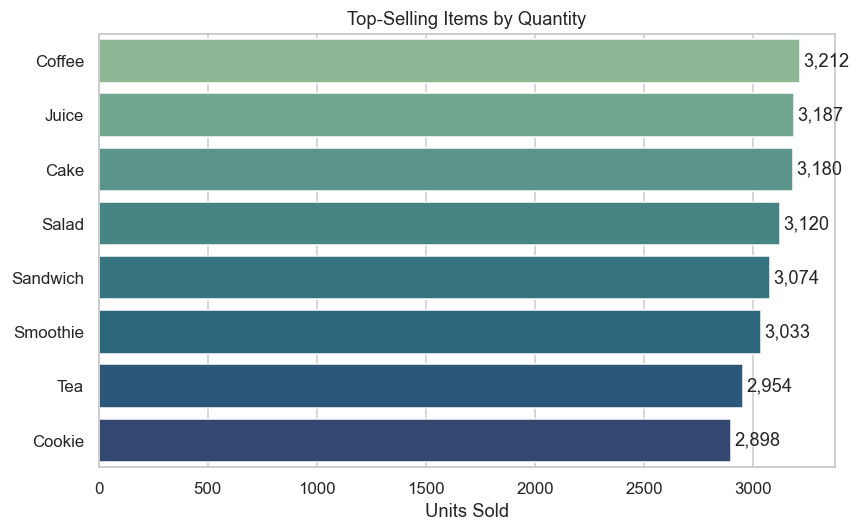

item
Coffee      3212
Juice       3187
Cake        3180
Salad       3120
Sandwich    3074
Smoothie    3033
Tea         2954
Cookie      2898
Name: quantity, dtype: Int64

In [22]:
top_items = (
    df.dropna(subset=["item"])
    .groupby("item")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top_items.values, y=top_items.index, hue=top_items.index,
            palette="crest", legend=False, ax=ax)
ax.set_xlabel("Units Sold")
ax.set_ylabel("")
ax.set_title("Top-Selling Items by Quantity")
for i, v in enumerate(top_items.values):
    ax.text(v + 15, i, f"{v:,.0f}", va="center")
plt.tight_layout()
plt.show()

top_items


### Revenue by Item

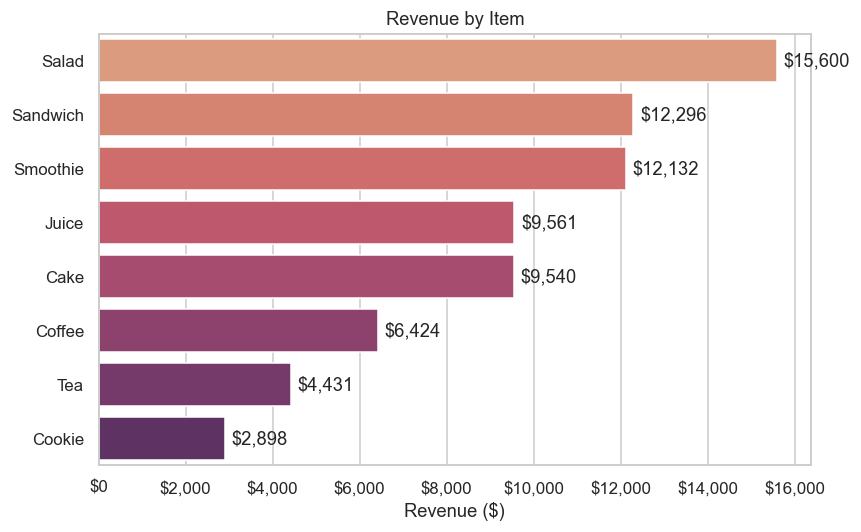

item
Salad      15,600.00
Sandwich   12,296.00
Smoothie   12,132.00
Juice       9,561.00
Cake        9,540.00
Coffee      6,424.00
Tea         4,431.00
Cookie      2,898.00
Name: revenue, dtype: Float64

In [23]:
item_revenue = (
    df.dropna(subset=["item"])
    .groupby("item")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=item_revenue.values, y=item_revenue.index, hue=item_revenue.index,
            palette="flare", legend=False, ax=ax)
ax.set_xlabel("Revenue ($)")
ax.set_ylabel("")
ax.set_title("Revenue by Item")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
for i, v in enumerate(item_revenue.values):
    ax.text(v + 150, i, f"${v:,.0f}", va="center")
plt.tight_layout()
plt.show()

item_revenue


### Payment Method Analysis

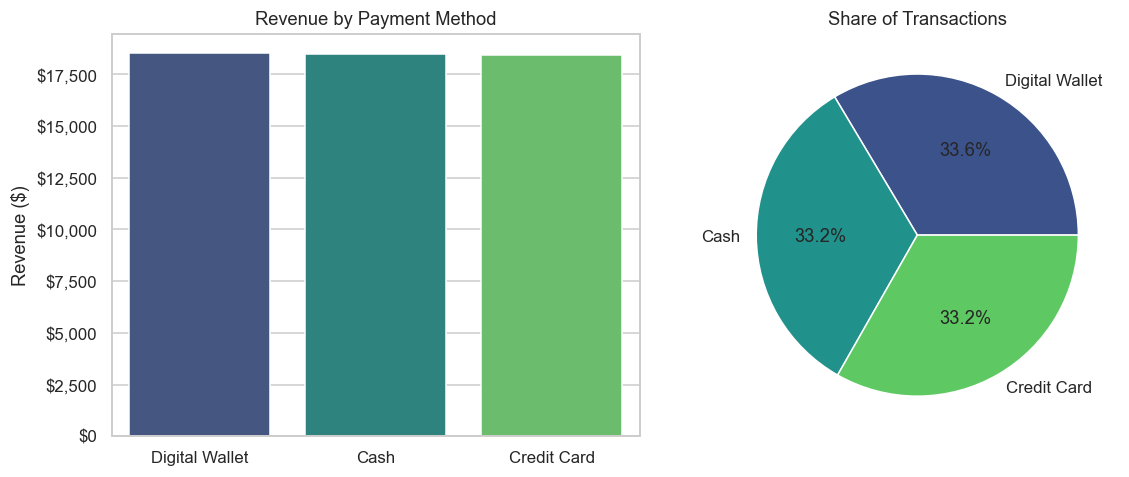

,transactions,total_revenue,avg_transaction
payment_method,,,
Digital Wallet,2068,"18,530.00",8.96
Cash,2044,"18,486.00",9.04
Credit Card,2047,"18,441.00",9.01


In [24]:
payment_analysis = (
    df.dropna(subset=["payment_method"])
    .groupby("payment_method")["revenue"]
    .agg(transactions="count", total_revenue="sum", avg_transaction="mean")
    .sort_values("total_revenue", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.barplot(x=payment_analysis.index, y=payment_analysis["total_revenue"],
            hue=payment_analysis.index, palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Revenue by Payment Method")
axes[0].set_ylabel("Revenue ($)")
axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

axes[1].pie(payment_analysis["transactions"], labels=payment_analysis.index,
            autopct="%1.1f%%", colors=sns.color_palette("viridis", len(payment_analysis)))
axes[1].set_title("Share of Transactions")

plt.tight_layout()
plt.show()

payment_analysis


### Monthly Sales Trend

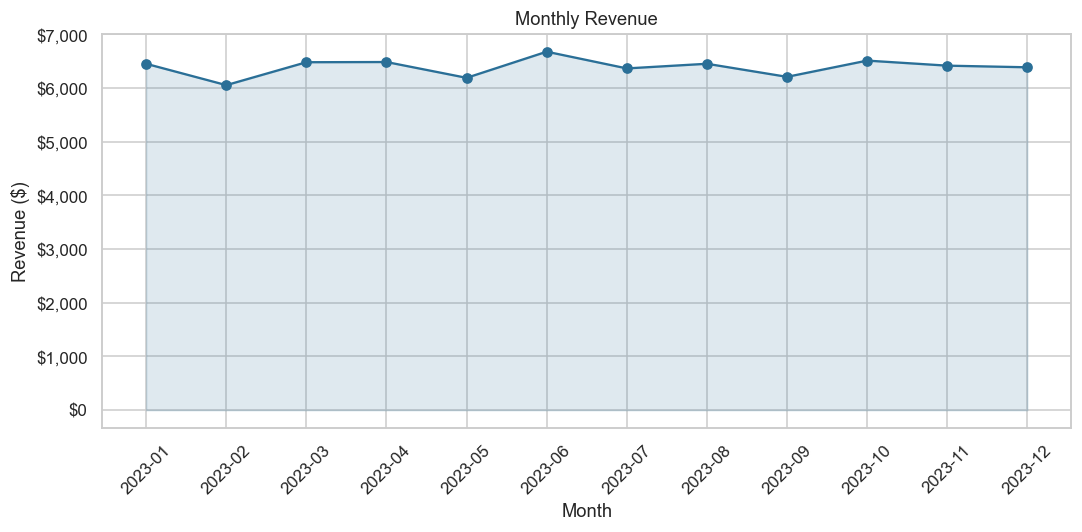

month
2023-01   6,452.50
2023-02   6,055.00
2023-03   6,482.00
2023-04   6,485.50
2023-05   6,191.00
2023-06   6,678.00
2023-07   6,366.50
2023-08   6,453.00
2023-09   6,209.50
2023-10   6,512.00
2023-11   6,418.00
2023-12   6,387.50
Name: revenue, dtype: Float64

In [25]:
monthly_sales = (
    df.dropna(subset=["transaction_date"])
    .assign(month=lambda d: d["transaction_date"].dt.to_period("M").astype(str))
    .groupby("month")["revenue"]
    .sum()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_sales.index, monthly_sales.values, marker="o", color="#2a6f97")
ax.fill_between(range(len(monthly_sales)), monthly_sales.values, alpha=0.15, color="#2a6f97")
ax.set_title("Monthly Revenue")
ax.set_ylabel("Revenue ($)")
ax.set_xlabel("Month")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_sales


### Highest-Value Transaction

In [26]:
highest_transaction = df.loc[df["revenue"].idxmax()]
highest_transaction


transaction_id                TXN_2548360
item                                Salad
quantity                                5
price_per_unit                       5.00
total_spent                         25.00
payment_method                       Cash
location                         Takeaway
transaction_date      2023-11-07 00:00:00
calculated_revenue                  25.00
revenue                             25.00
Name: 10, dtype: object

# Exporting Report

In [27]:
report_path = OUTPUT_DIR / "sales_report.xlsx"

with pd.ExcelWriter(report_path, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Cleaned Data", index=False)
    top_items.to_excel(writer, sheet_name="Top Items")
    item_revenue.to_excel(writer, sheet_name="Item Revenue")
    monthly_sales.to_excel(writer, sheet_name="Monthly Sales")
    payment_analysis.to_excel(writer, sheet_name="Payment Analysis")

print("Cleaned CSV:  ", (OUTPUT_DIR / "cleaned_sales.csv").resolve())
print("Excel Report: ", report_path.resolve())


Cleaned CSV:   /Users/anubhavkukreti/Desktop/ecommerce-sales-analysis/outputs/cleaned_sales.csv
Excel Report:  /Users/anubhavkukreti/Desktop/ecommerce-sales-analysis/outputs/sales_report.xlsx
